# 🌲 PART 1: RANDOM FOREST OPTIMIZATION
---
Collaborators 💬🤝🤖
- Amy Zhang
- ChatGPT
---
🎯 Goal:
Hyperparameter optimization on two Random Forest setups to identify key features.

---

# 1. Import Libraries and Datasets

In [49]:
# 📊 Data manipulation and analysis
import pandas as pd          # Tabular data handling
import numpy as np           # Numerical operations

# 📈 Visualization
import seaborn as sns        # For visualizations (e.g., heatmaps, bar plots)
import matplotlib.pyplot as plt  # Core plotting library

# 🗂️ File operations
import os                    # For file system tasks (e.g., saving figures)

# 🔧 Utility functions
import operator              # For functional tools (e.g., sorting feature importances)

# 🎯 Model building: Random Forest
from sklearn.ensemble import RandomForestClassifier   # Our model
from sklearn.tree import plot_tree                    # For plotting individual decision trees
from sklearn.metrics import accuracy_score            # For model evaluation

# 🧪 Data splitting
from sklearn.model_selection import train_test_split  # Split data into training/test sets

# 🔒 Reproducibility
np.random.seed(42)


In [50]:
weather_df = pd.read_csv('Dataset-weather-prediction-dataset-processed.csv')

In [51]:
# Import 'pleasant_weather'
pleasant_weather = pd.read_csv('pleasant_weather_Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv')

# PART I. Optimized Random Forest on Full Dataset

In [52]:
# Drop all columns that start with TOURS_, ROMA_, or GDANSK_
weather_df = weather_df.drop(columns=[
    col for col in weather_df.columns
    if col.startswith('TOURS_') or col.startswith('ROMA_') or col.startswith('GDANSK_')
])


In [53]:
# Drop all columns that end with '_snow_depth' and '_wind_speed'
weather_df = weather_df.drop(columns=[
    col for col in weather_df.columns
    if col.endswith('_snow_depth') or col.endswith('_wind_speed')
])


In [54]:
### Copy LJUBLJANA_cloud_cover → assign as KASSEL_cloud_cover
### Copy SONNBLICK_pressure → assign as MUNCHENB_pressure
### Copy OSLO_humidity → assign as STOCKHOLM_humidity

# Fill in the missing columns using nearby station data
weather_df['KASSEL_cloud_cover'] = weather_df['LJUBLJANA_cloud_cover']
weather_df['MUNCHENB_pressure'] = weather_df['SONNBLICK_pressure']
weather_df['STOCKHOLM_humidity'] = weather_df['OSLO_humidity']


In [55]:
# Convert date to datetime and extract decade
weather_df['date'] = pd.to_datetime(weather_df['DATE'], format="%Y%m%d")
weather_df['year'] = weather_df['date'].dt.year
weather_df['decade'] = (weather_df['year'] // 10) * 10


In [56]:
### Select for 2010s
weather_2010s = weather_df[weather_df['decade'] == 2010].copy()


In [57]:
pleasant_weather['date'] = pd.to_datetime(pleasant_weather['DATE'], format="%Y%m%d")
pleasant_weather['year'] = pleasant_weather['date'].dt.year
pleasant_weather['decade'] = (pleasant_weather['year'] // 10) * 10


In [58]:
pleasant_2010s = pleasant_weather[pleasant_weather['decade'] == 2010].copy()


In [59]:
### Make sure their date indexes align.

weather_2010s = weather_2010s.sort_values('date').reset_index(drop=True)
pleasant_2010s = pleasant_2010s.sort_values('date').reset_index(drop=True)


# 3. Prepare Features Matrix & Split

In [60]:
# 1. Prepare features (X)
# Drop columns not needed for modeling
X = weather_2010s.drop(columns=['DATE', 'date', 'year', 'decade', 'MONTH'])

# 2. Prepare target (y)
# Collapse all stations' pleasantness columns into a single boolean per day
pleasant_cols = [col for col in pleasant_2010s.columns if '_pleasant_weather' in col]
y = pleasant_2010s[pleasant_cols].any(axis=1).astype(int)

# 3. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Set Up Hyperparameter Search Space

In [61]:
from sklearn.model_selection import RandomizedSearchCV
# from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Define search space
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 20),
    'max_features': ['sqrt', 'log2'],  # removed 'auto'
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'criterion': ['gini', 'entropy']
}


# 5. Run RandomizedSearchCV

In [62]:
# Set up the model
rf = RandomForestClassifier(random_state=42)

# Randomized search with 10 iterations
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,             # Try more later if you want
    cv=3,                  # 3-fold cross-validation
    n_jobs=-1,             # Use all cores
    verbose=1,
    random_state=42
)

# Fit search on training data
search.fit(X_train, y_train)

# Best model
best_rf = search.best_estimator_

print("Best parameters:", search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'criterion': 'entropy', 'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 108}


# 6. Predict & Evaluate with the Best Model

### ✅ What it's doing:
> You’re using your best_rf model — the one returned by RandomizedSearchCV, already trained using only the training set (X_train, y_train) via cross-validation.

> Now, you’re calling .predict() on X_test, which is the held-out test data — data that was never seen during training or hyperparameter tuning.

> Then you're scoring its predictions against y_test.

**🔐 So — no data leakage here! 🎉**

In [63]:
### Compare Tuned vs. Untuned Accuracy
from sklearn.metrics import accuracy_score

# Untuned
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred_untuned = clf.predict(X_test)
acc_untuned = accuracy_score(y_test, y_pred_untuned)
print(f"Untuned RF accuracy: {acc_untuned:.3f}")

# Tuned
y_pred_tuned = best_rf.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned RF accuracy: {acc_tuned:.3f}")


Untuned RF accuracy: 0.967
Tuned RF accuracy: 0.970


## Compare Hyperparameters (tuned v untuned)

---

### 🔧 Untuned Model (defaults except `n_estimators`):

| Hyperparameter      | Value    |
| ------------------- | -------- |
| `criterion`         | `'gini'` |
| `max_depth`         | `None`   |
| `max_features`      | `'sqrt'` |
| `min_samples_leaf`  | `1`      |
| `min_samples_split` | `2`      |
| `n_estimators`      | `100`    |

---

### 🧪 Tuned Model (RandomizedSearchCV):

| Hyperparameter      | Tuned Value |
| ------------------- | ----------- |
| `criterion`         | `'entropy'` |
| `max_depth`         | `14`        |
| `max_features`      | `'sqrt'`    |
| `min_samples_leaf`  | `1`         |
| `min_samples_split` | `4`         |
| `n_estimators`      | `108`       |

---

### 🔍 Key Differences

| What Changed?           | Untuned Value | Tuned Value | Effect                                                                            |
| ----------------------- | ------------- | ----------- | --------------------------------------------------------------------------------- |
| **Criterion**           | `'gini'`      | `'entropy'` | Entropy often gives slightly better splits when classes are imbalanced or nuanced |
| **max\_depth**          | `None`        | `14`        | Prevents trees from growing too deep (overfitting)                                |
| **min\_samples\_split** | `2`           | `4`         | Slightly more conservative in splitting nodes — improves generalization           |
| **n\_estimators**       | `100`         | `108`       | Marginal increase in ensemble strength                                            |
| **Others**              | Same          | Same        | `max_features` and `min_samples_leaf` stayed unchanged                            |

---

### 🎯 So What?

Even if **accuracy stayed high**, this tuned model is:

* **Shallower** (less likely to overfit)
* **More deliberate** in splitting (min samples split = 4)
* **Potentially more interpretable** and faster
* Optimized via entropy instead of default gini

In sum: still getting \~97% accuracy, but doing it with smarter structure 🎓🌲


# 7. Feature Importances -- Updated

In [64]:
importances = best_rf.feature_importances_

# Reshape back to (15 stations, 9 features)
important_reshaped = importances.reshape(-1, 15, 9)

# Sum importances per station
station_importances = important_reshaped.sum(axis=2)[0]


# 8. Visualizations

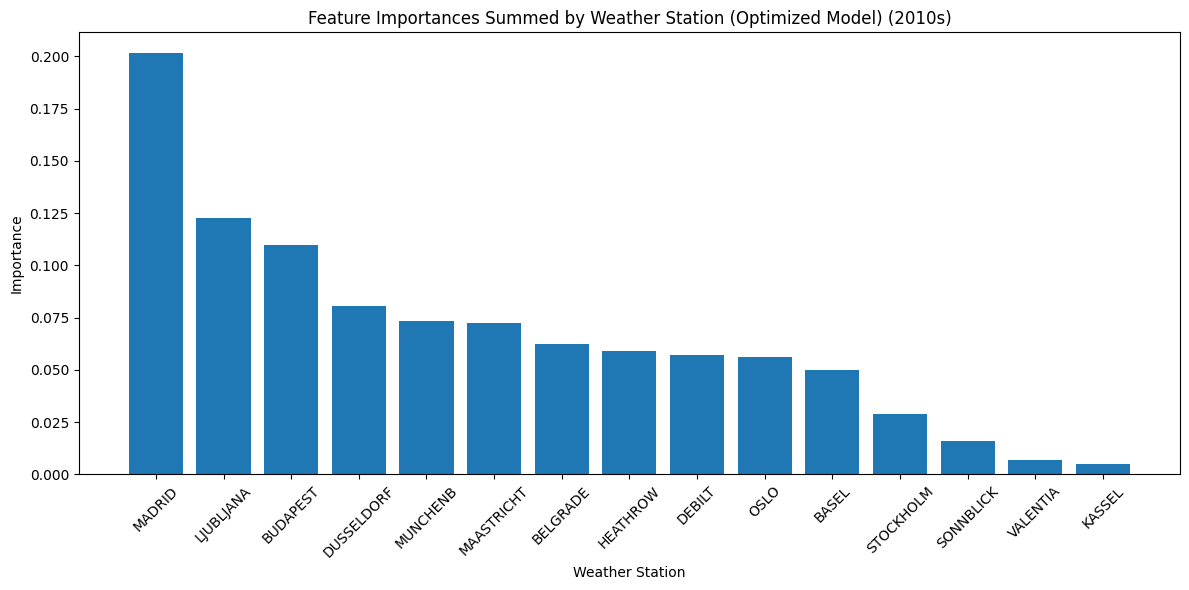

In [65]:
stations = [col.split('_')[0] for col in pleasant_cols]

# Sort indices by descending importance
sorted_idx = np.argsort(station_importances)[::-1]

# Apply sorting to stations and importances
stations_sorted = [stations[i] for i in sorted_idx]
importances_sorted = station_importances[sorted_idx]

plt.figure(figsize=(12, 6))
plt.bar(stations_sorted, importances_sorted)
plt.title('Feature Importances Summed by Weather Station (Optimized Model) (2010s)')
plt.xlabel('Weather Station')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


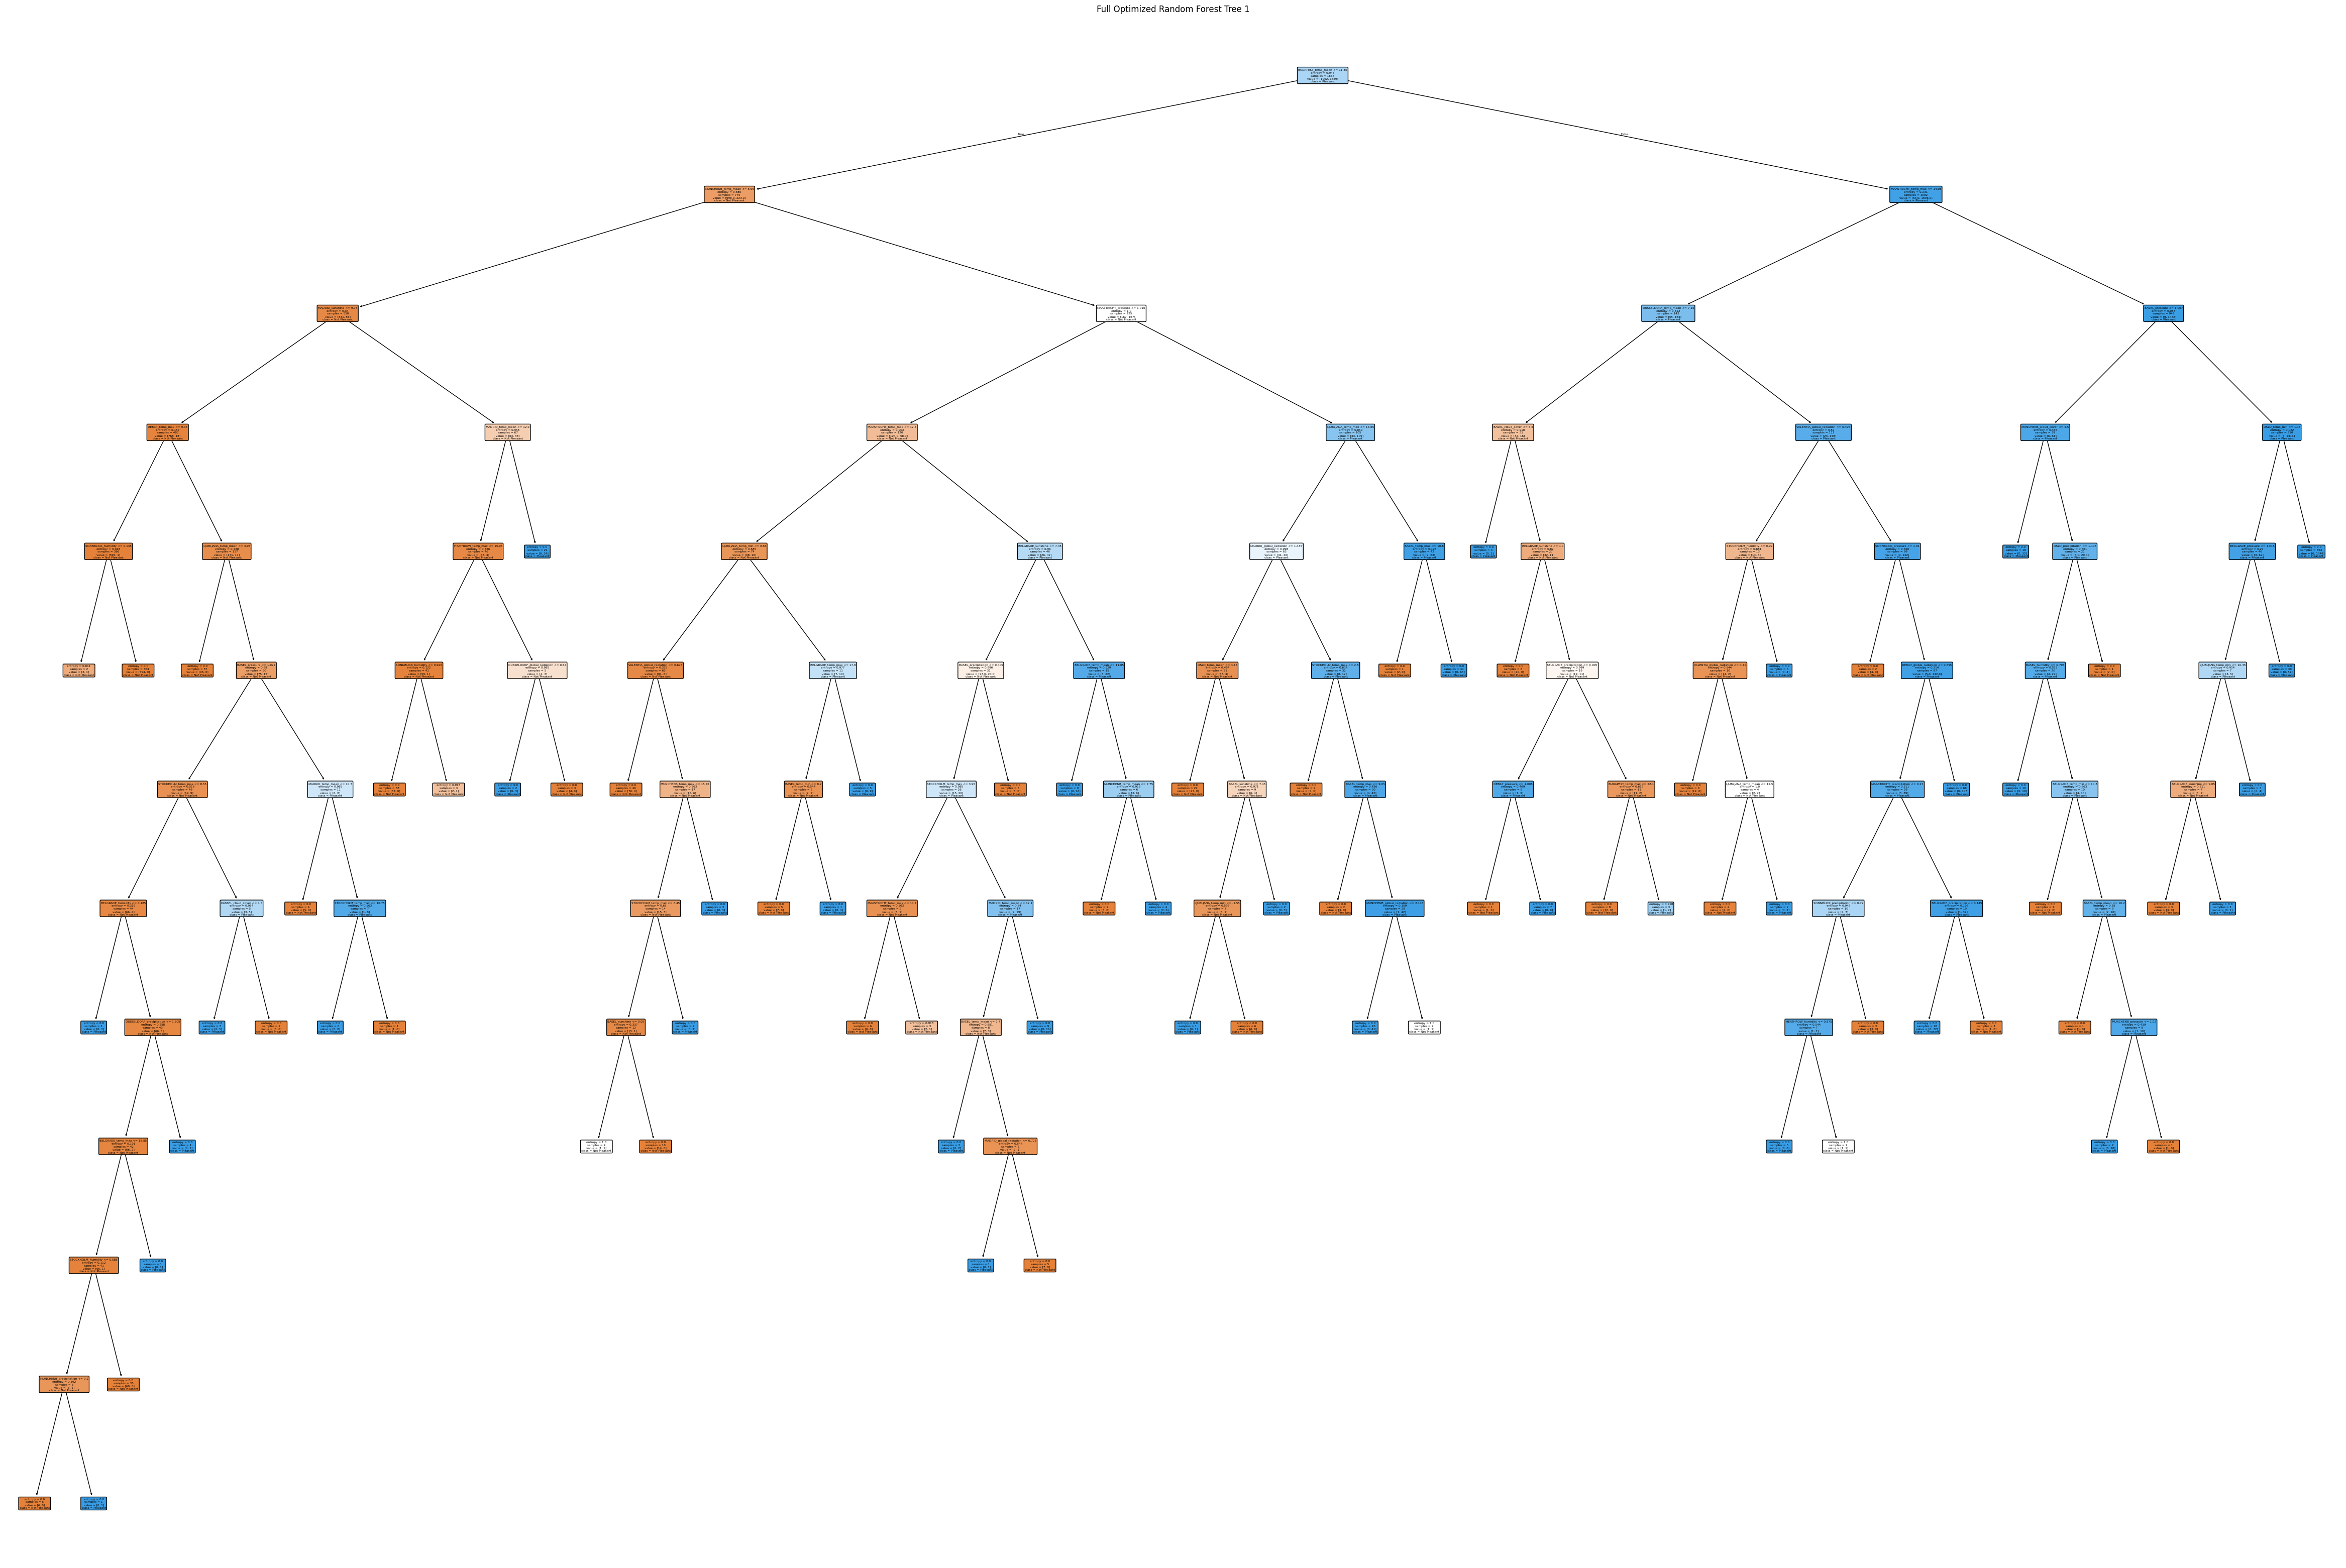

In [66]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(60, 40))  # Bigger fig to handle the whole tree
plot_tree(
    best_rf.estimators_[0],
    filled=True,
    rounded=True,
    feature_names=X.columns,
    class_names=["Not Pleasant", "Pleasant"],
    max_depth=None  # <-- This is the key
)
plt.title("Full Optimized Random Forest Tree 1")
plt.show()


# PART II. Random Forests for Each of the Top 3 Weather Stations

In [67]:
weather_df = weather_df.drop(columns=['MONTH'])

# 1. Dataframe Subsetting (3) & Prep for ML

In [68]:
# Top 3 station mappings: code → full name
top_stations = {
    'MAD': 'MADRID',
    'BUD': 'BUDAPEST',
    'LJU': 'LJUBLJANA'
}

# Container to hold all data splits
data_splits = {}

for code, full_name in top_stations.items():
    # 1. Extract weather feature columns for this station (e.g., MADRID_temp_max, etc.)
    weather_cols = [col for col in weather_df.columns if col.startswith(full_name)]
    meta_cols = ['DATE', 'date', 'year', 'decade']  # To keep for possible filtering
    weather_subset = weather_df[meta_cols + weather_cols].copy()

    # 2. Extract pleasantness column for this station
    pleasant_col = f"{full_name}_pleasant_weather"
    pleasant_subset = pleasant_weather[meta_cols + [pleasant_col]].copy()

    # 3. Drop non-feature columns to get X and y
    X = weather_subset.drop(columns=meta_cols)
    y = pleasant_subset[pleasant_col]

    # 4. Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

    # 5. Save to dictionary
    data_splits[code] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'full_name': full_name
    }


# 2. Loop: Hyperparameter Tune + Evaluate Random Forests on Top 3 Stations

In [70]:
# Store results
rf_models = {}
rf_accuracies = {}

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

for code, data in data_splits.items():
    print(f"\n📡 Hyperparameter tuning RF for {data['full_name']}...")

    rf = RandomForestClassifier(random_state=42)

    search = RandomizedSearchCV(
        rf,
        param_distributions=param_dist,
        n_iter=10,  # start small to test
        cv=3,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )

    search.fit(data['X_train'], data['y_train'])

    best_rf = search.best_estimator_

    accuracy = best_rf.score(data['X_test'], data['y_test'])

    rf_models[code] = best_rf
    rf_accuracies[code] = accuracy

    print(f"✅ Best params for {data['full_name']}: {search.best_params_}")
    print(f"✅ Accuracy for {data['full_name']}: {accuracy:.3f}")


📡 Hyperparameter tuning RF for MADRID...
✅ Best params for MADRID: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy'}
✅ Accuracy for MADRID: 1.000

📡 Hyperparameter tuning RF for BUDAPEST...
✅ Best params for BUDAPEST: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'criterion': 'gini'}
✅ Accuracy for BUDAPEST: 1.000

📡 Hyperparameter tuning RF for LJUBLJANA...
✅ Best params for LJUBLJANA: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy'}
✅ Accuracy for LJUBLJANA: 1.000


## Compare Hyperparameters

---

### 🔍 Summary Table: Tuned Hyperparameters by Station

| Hyperparameter      | **MADRID**  | **BUDAPEST** | **LJUBLJANA** |
| ------------------- | ----------- | ------------ | ------------- |
| `n_estimators`      | 50          | 50           | 100           |
| `min_samples_split` | 2           | 5            | 2             |
| `min_samples_leaf`  | 2           | 1            | 4             |
| `max_features`      | `'log2'`    | `'log2'`     | `'log2'`      |
| `max_depth`         | `None`      | 5            | `None`        |
| `criterion`         | `'entropy'` | `'gini'`     | `'entropy'`   |
| **Accuracy**        | **1.000**   | **1.000**    | **1.000**     |

---

### 🔍 Interpretation by Station

#### 🟡 MADRID

* **Entropy** over Gini → suggests splits benefit from nuanced class separation
* **No max depth** → model benefits from full tree complexity
* **Min samples leaf = 2** → encourages some smoothing
* **Only 50 trees!** → clear patterns; less complexity needed

---

#### 🔵 BUDAPEST

* **Gini** instead of Entropy → simpler class structure
* **Shallow trees (max depth = 5)** → data separable quickly
* **Min split = 5, leaf = 1** → more conservative at first, but ends with tight leaf nodes
* **50 trees** again!


---

#### 🟢 LJUBLJANA

* **Entropy** again — subtle splits
* **More trees (100)** → more variation to capture?
* **Min leaf = 4** → wants smoothing/generalization
* **No depth limit** — likes to go deep
* **Split threshold = 2** — okay to start branching fast


---

### ❓So What?

Even with **identical accuracy (1.000!)**, the **paths to that result** are totally different. These tuned hyperparameters reflect:

* **Station-specific data structure**
* How much **complexity** each region's weather-pleasantness relationship needs
* The **efficiency** of the modeling — how far it needs to go to make accurate decisions


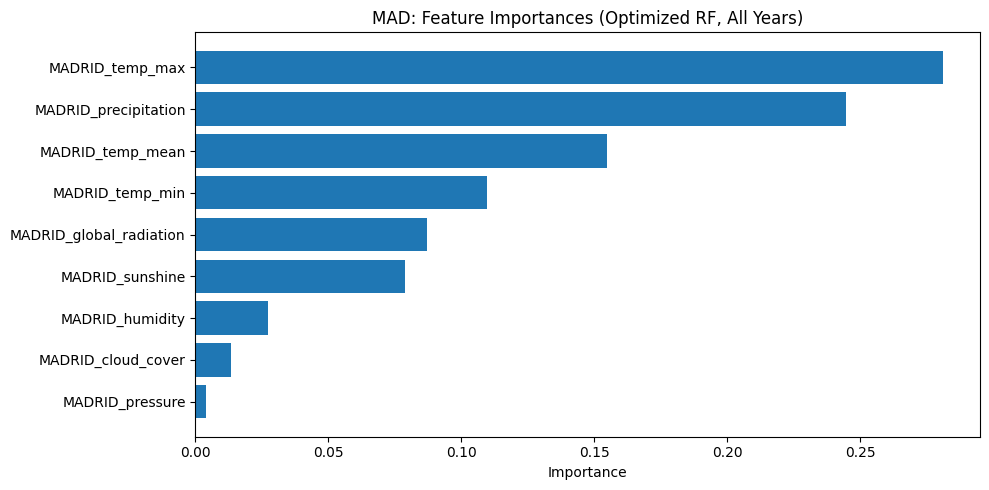

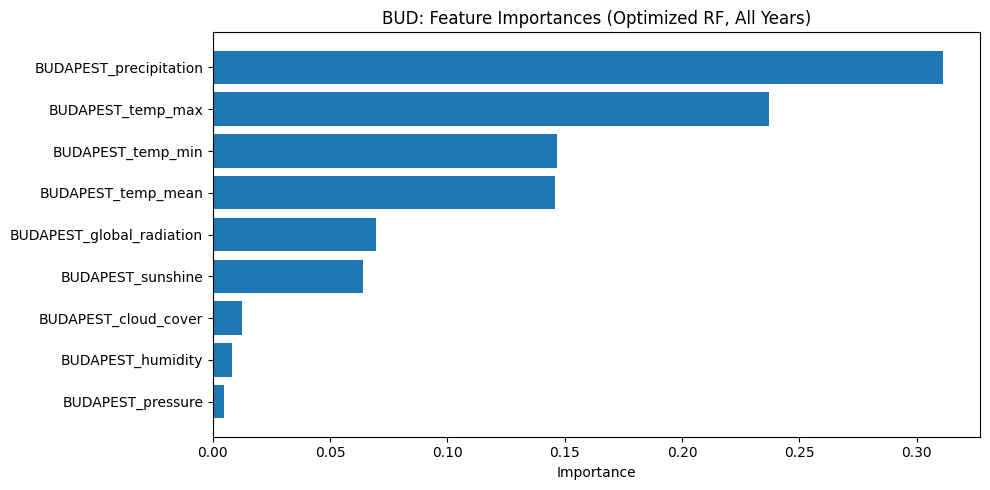

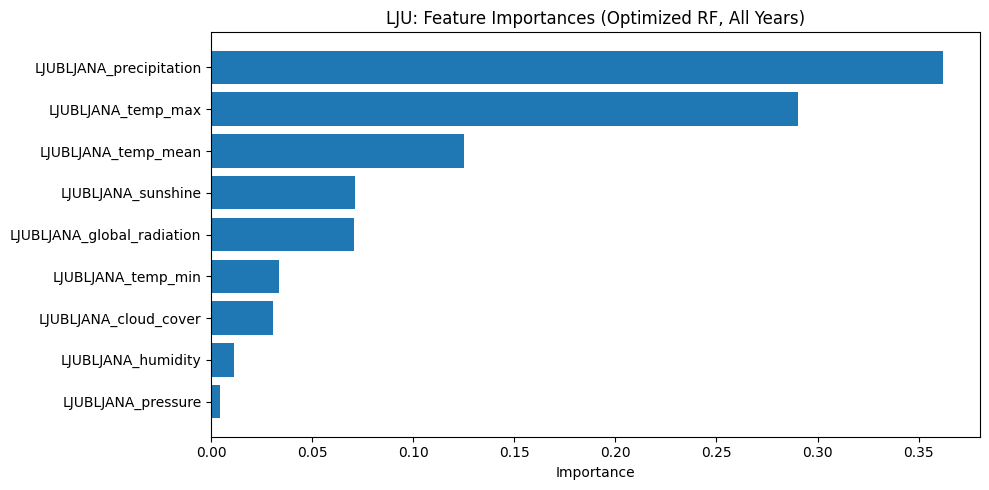

In [72]:
top3 = ['MAD', 'BUD', 'LJU']

for station in top3:
    clf = rf_models[station]  # <- tuned model!
    features = data_splits[station]['X_train'].columns
    importances = clf.feature_importances_

    # Sort features and importances in descending order
    sorted_idx = importances.argsort()[::-1]
    sorted_features = features[sorted_idx]
    sorted_importances = importances[sorted_idx]

    plt.figure(figsize=(10, 5))
    plt.barh(sorted_features, sorted_importances)
    plt.title(f"{station}: Feature Importances (Optimized RF, All Years)")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


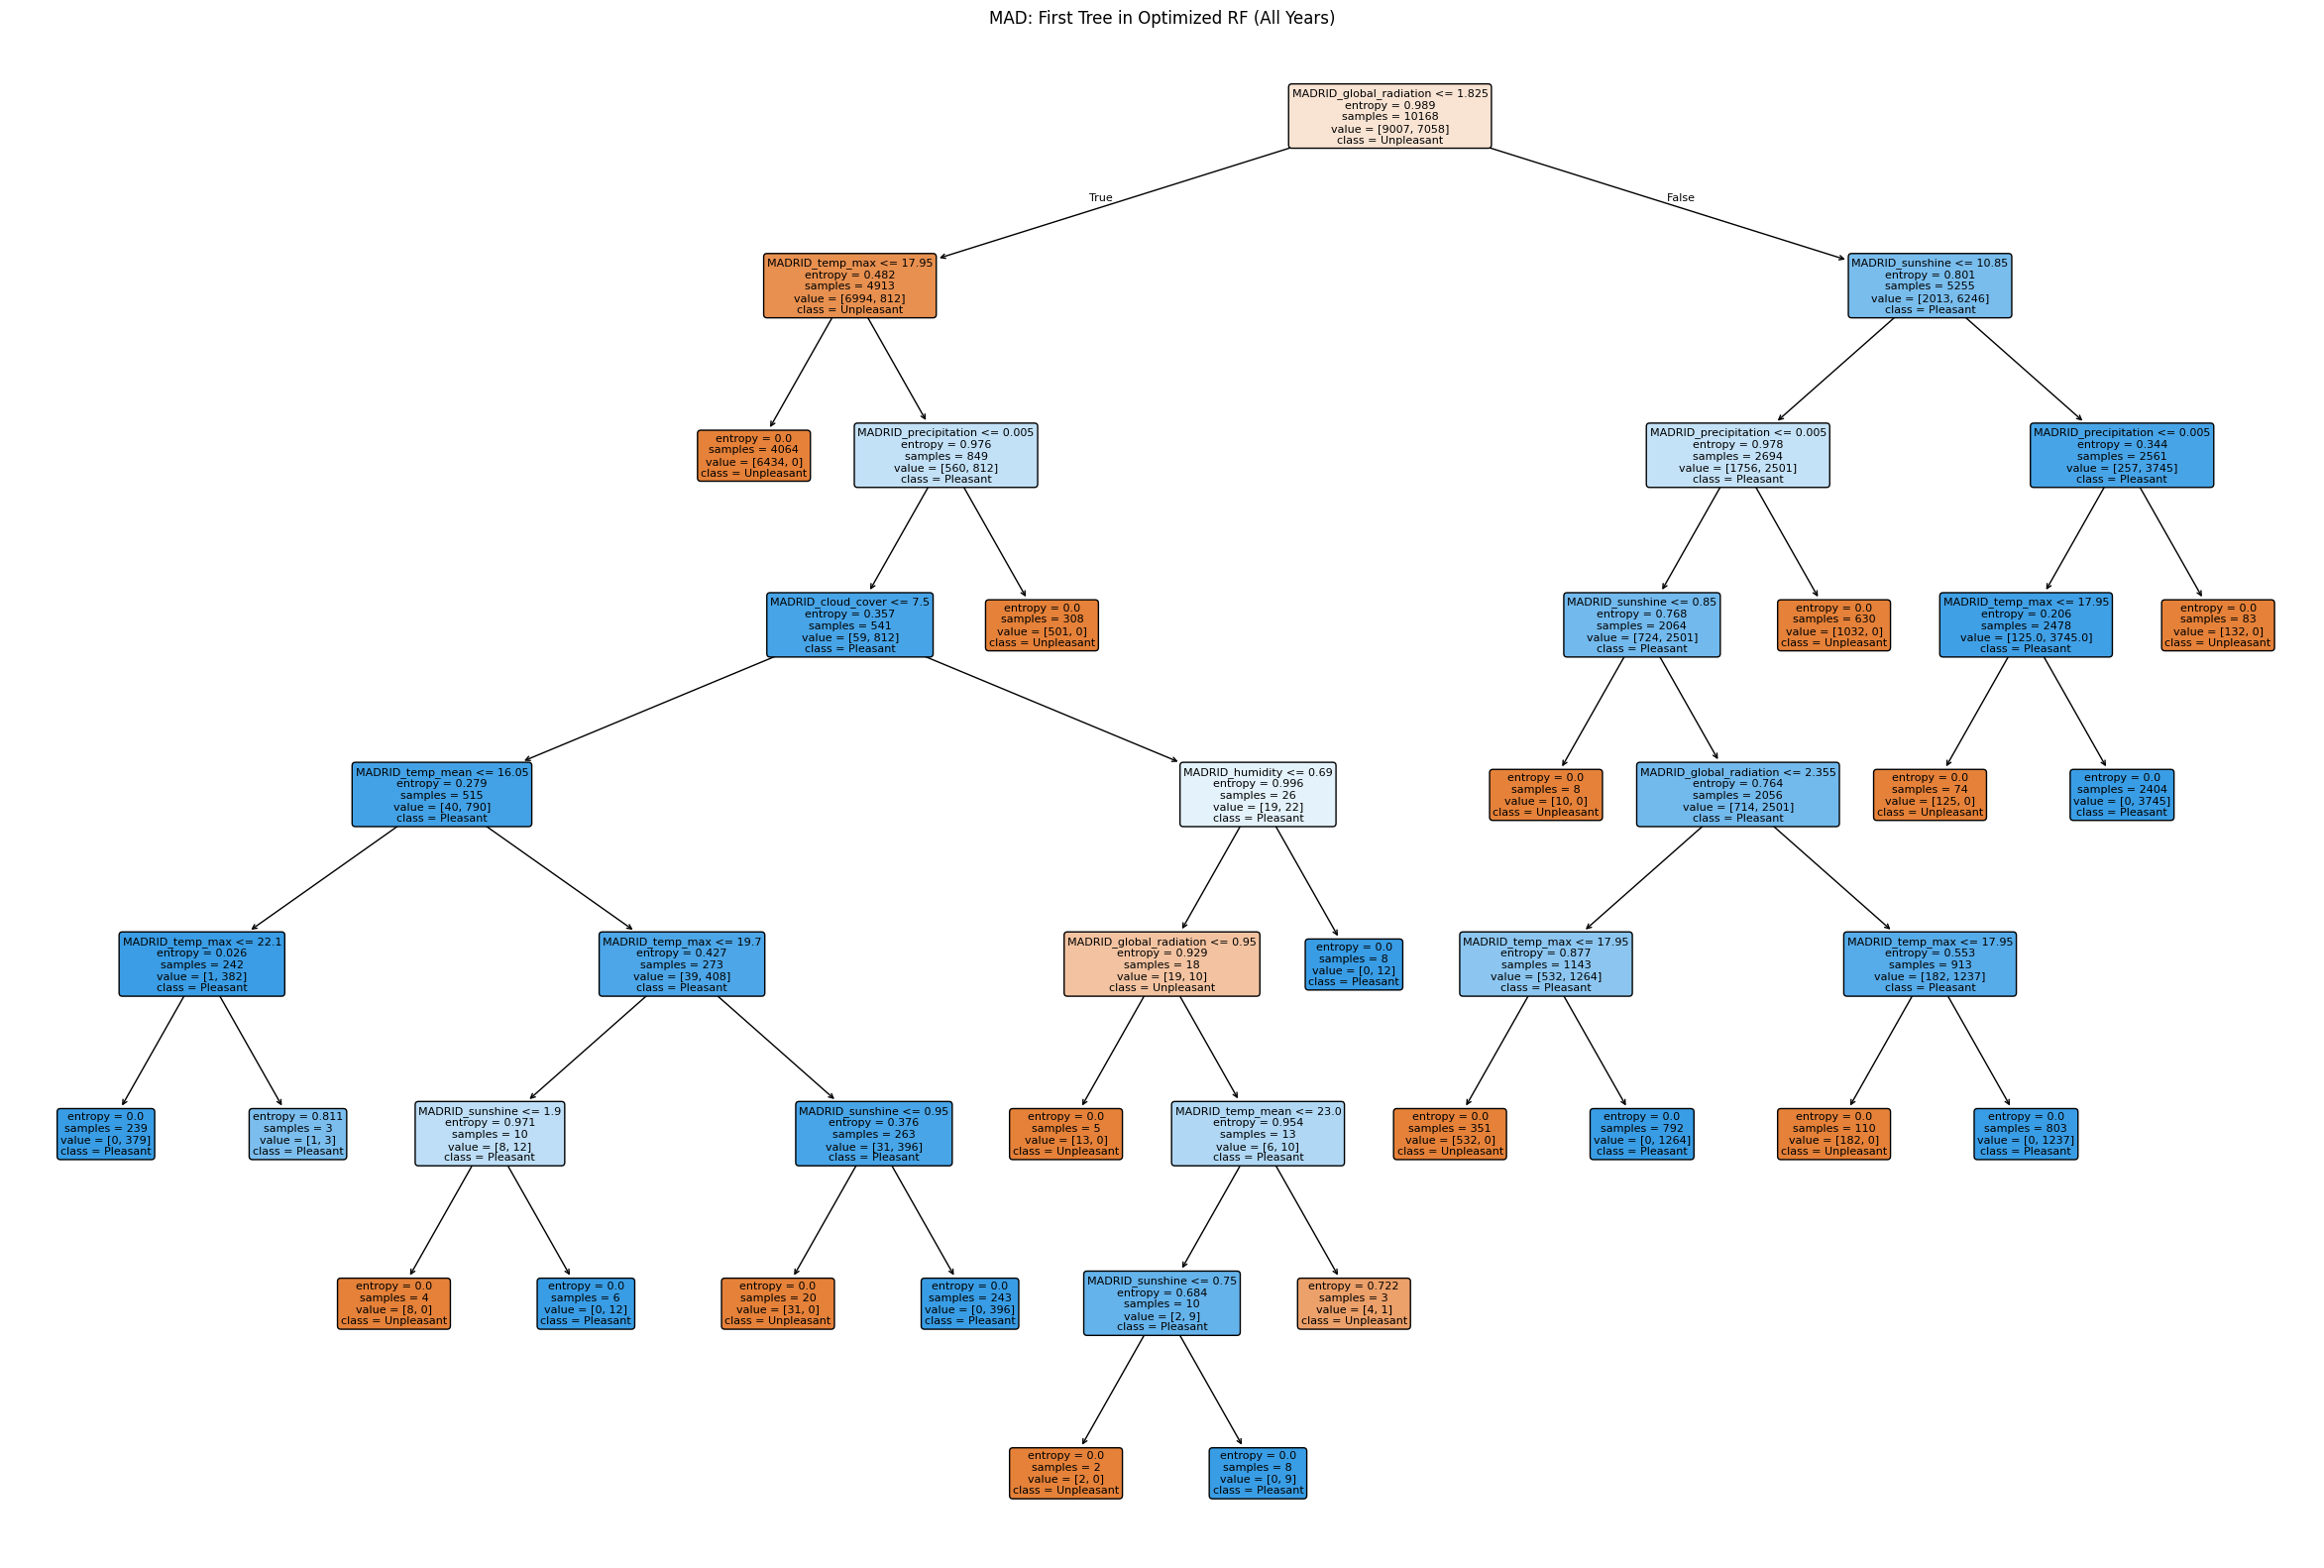

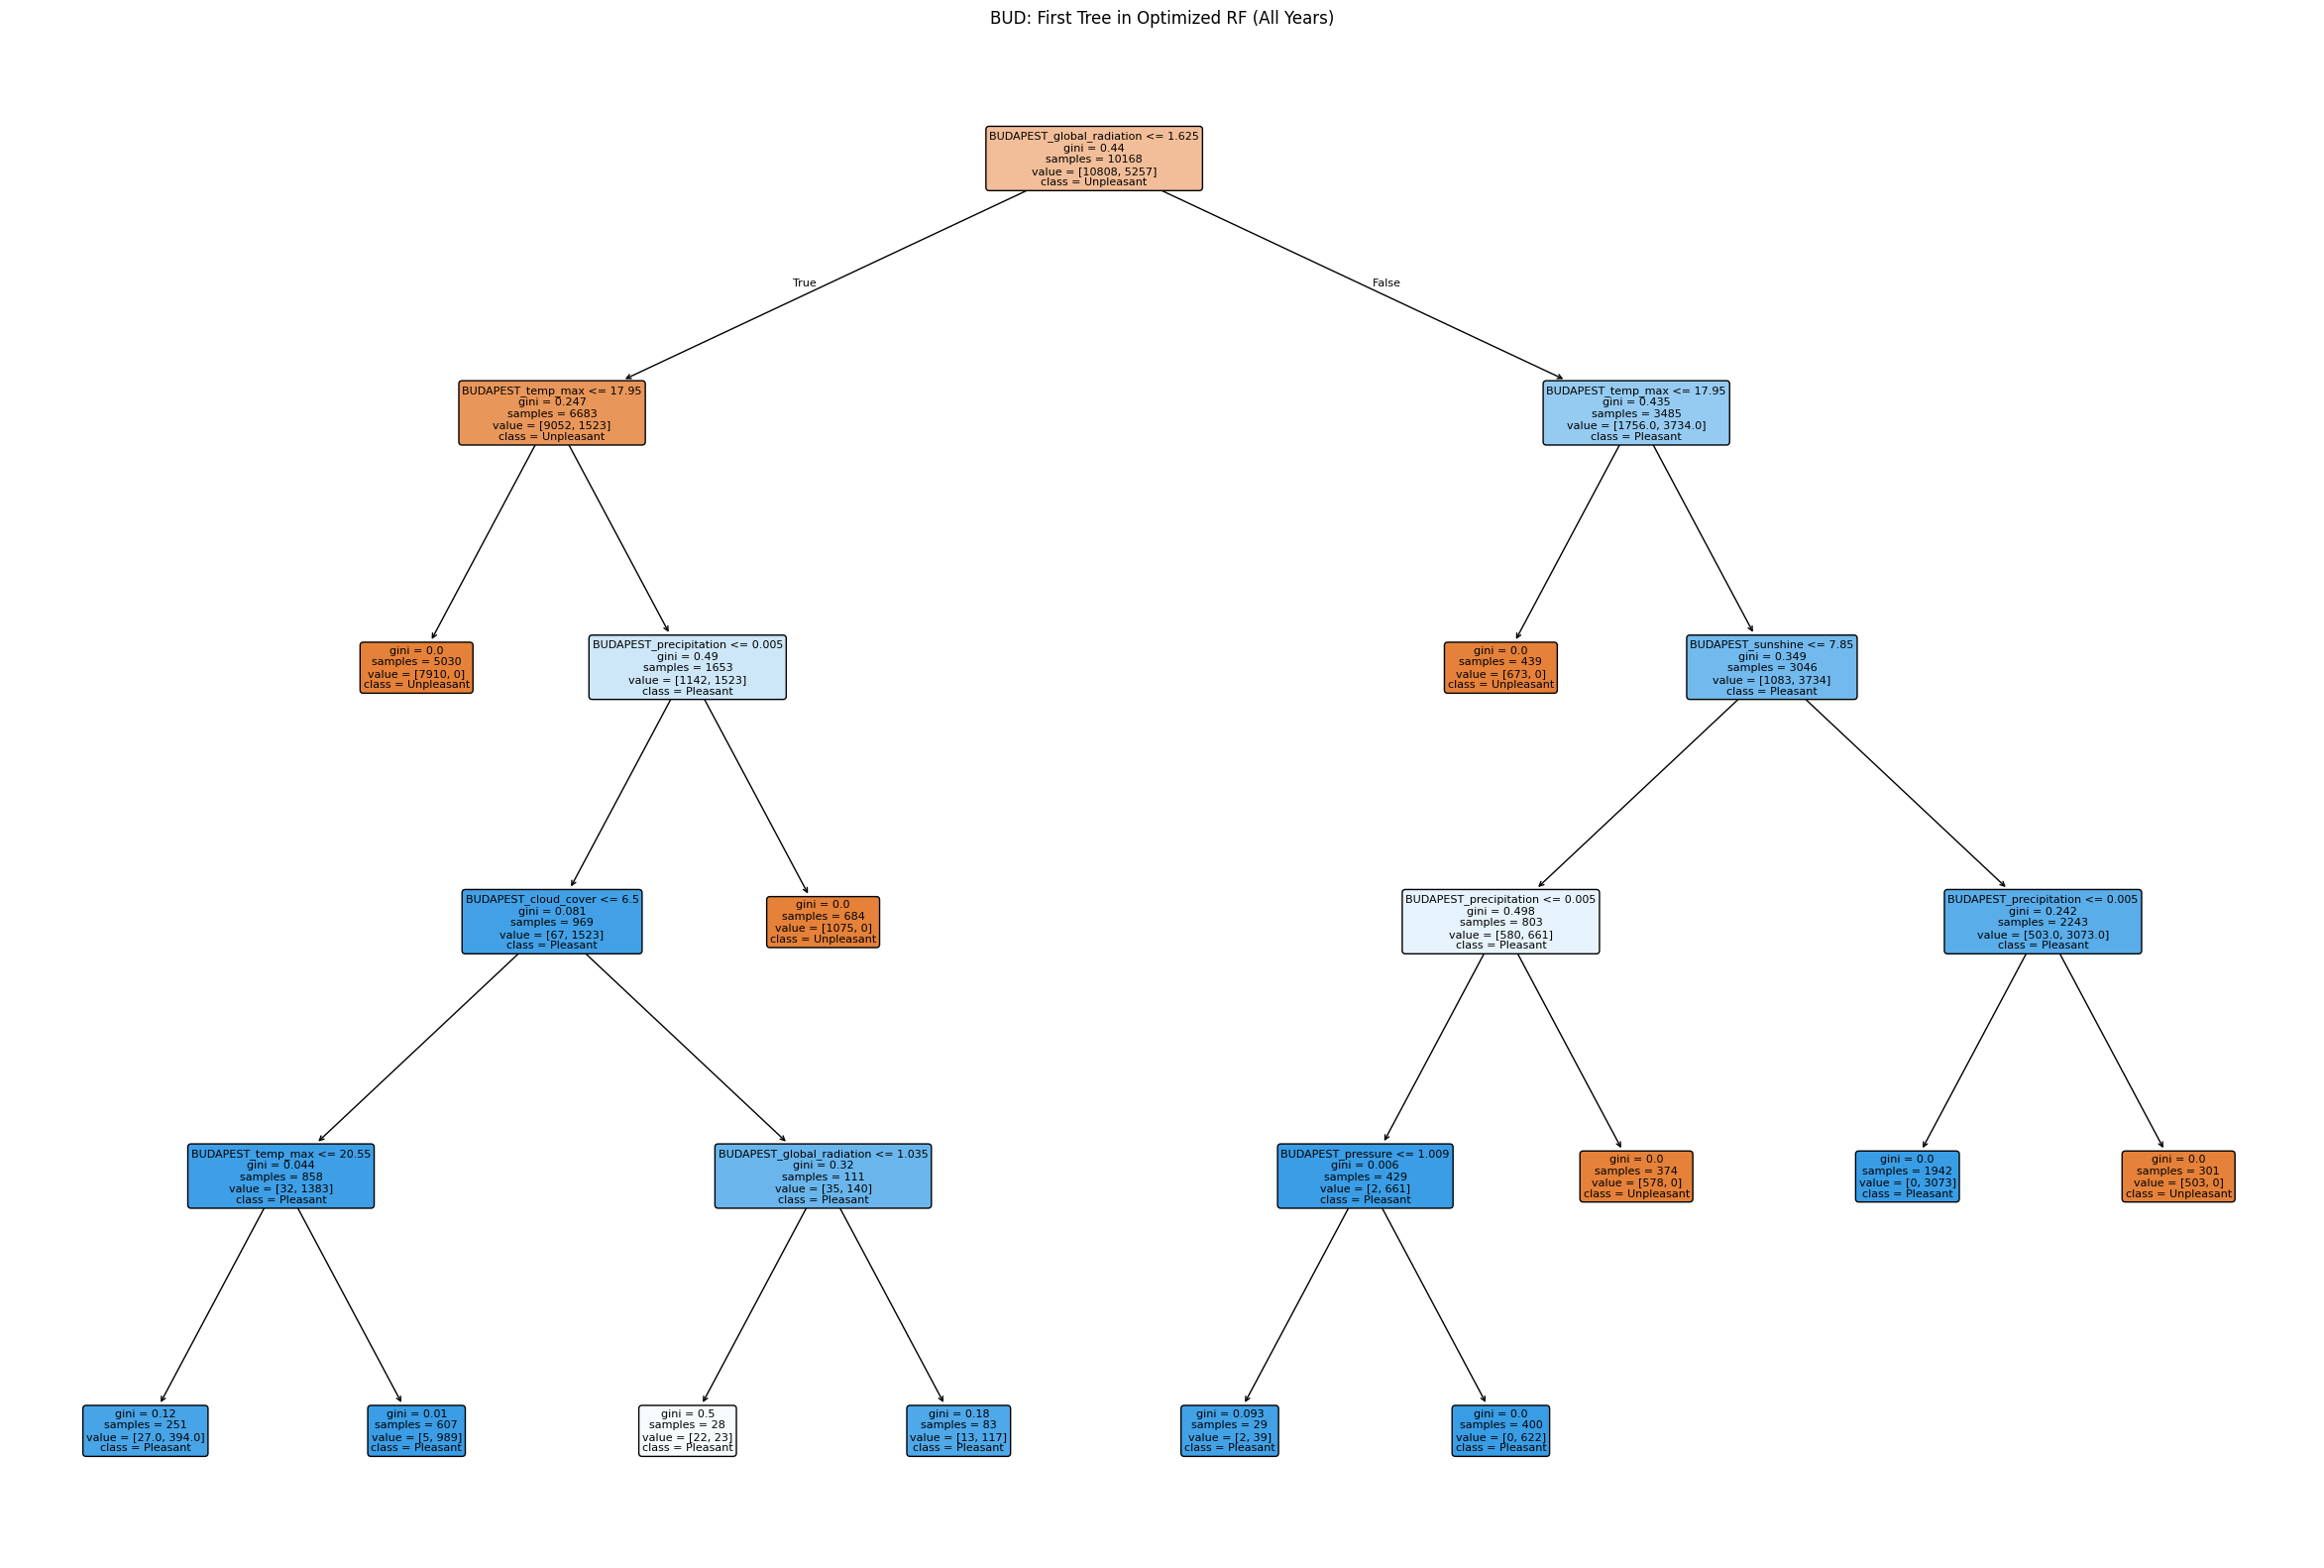

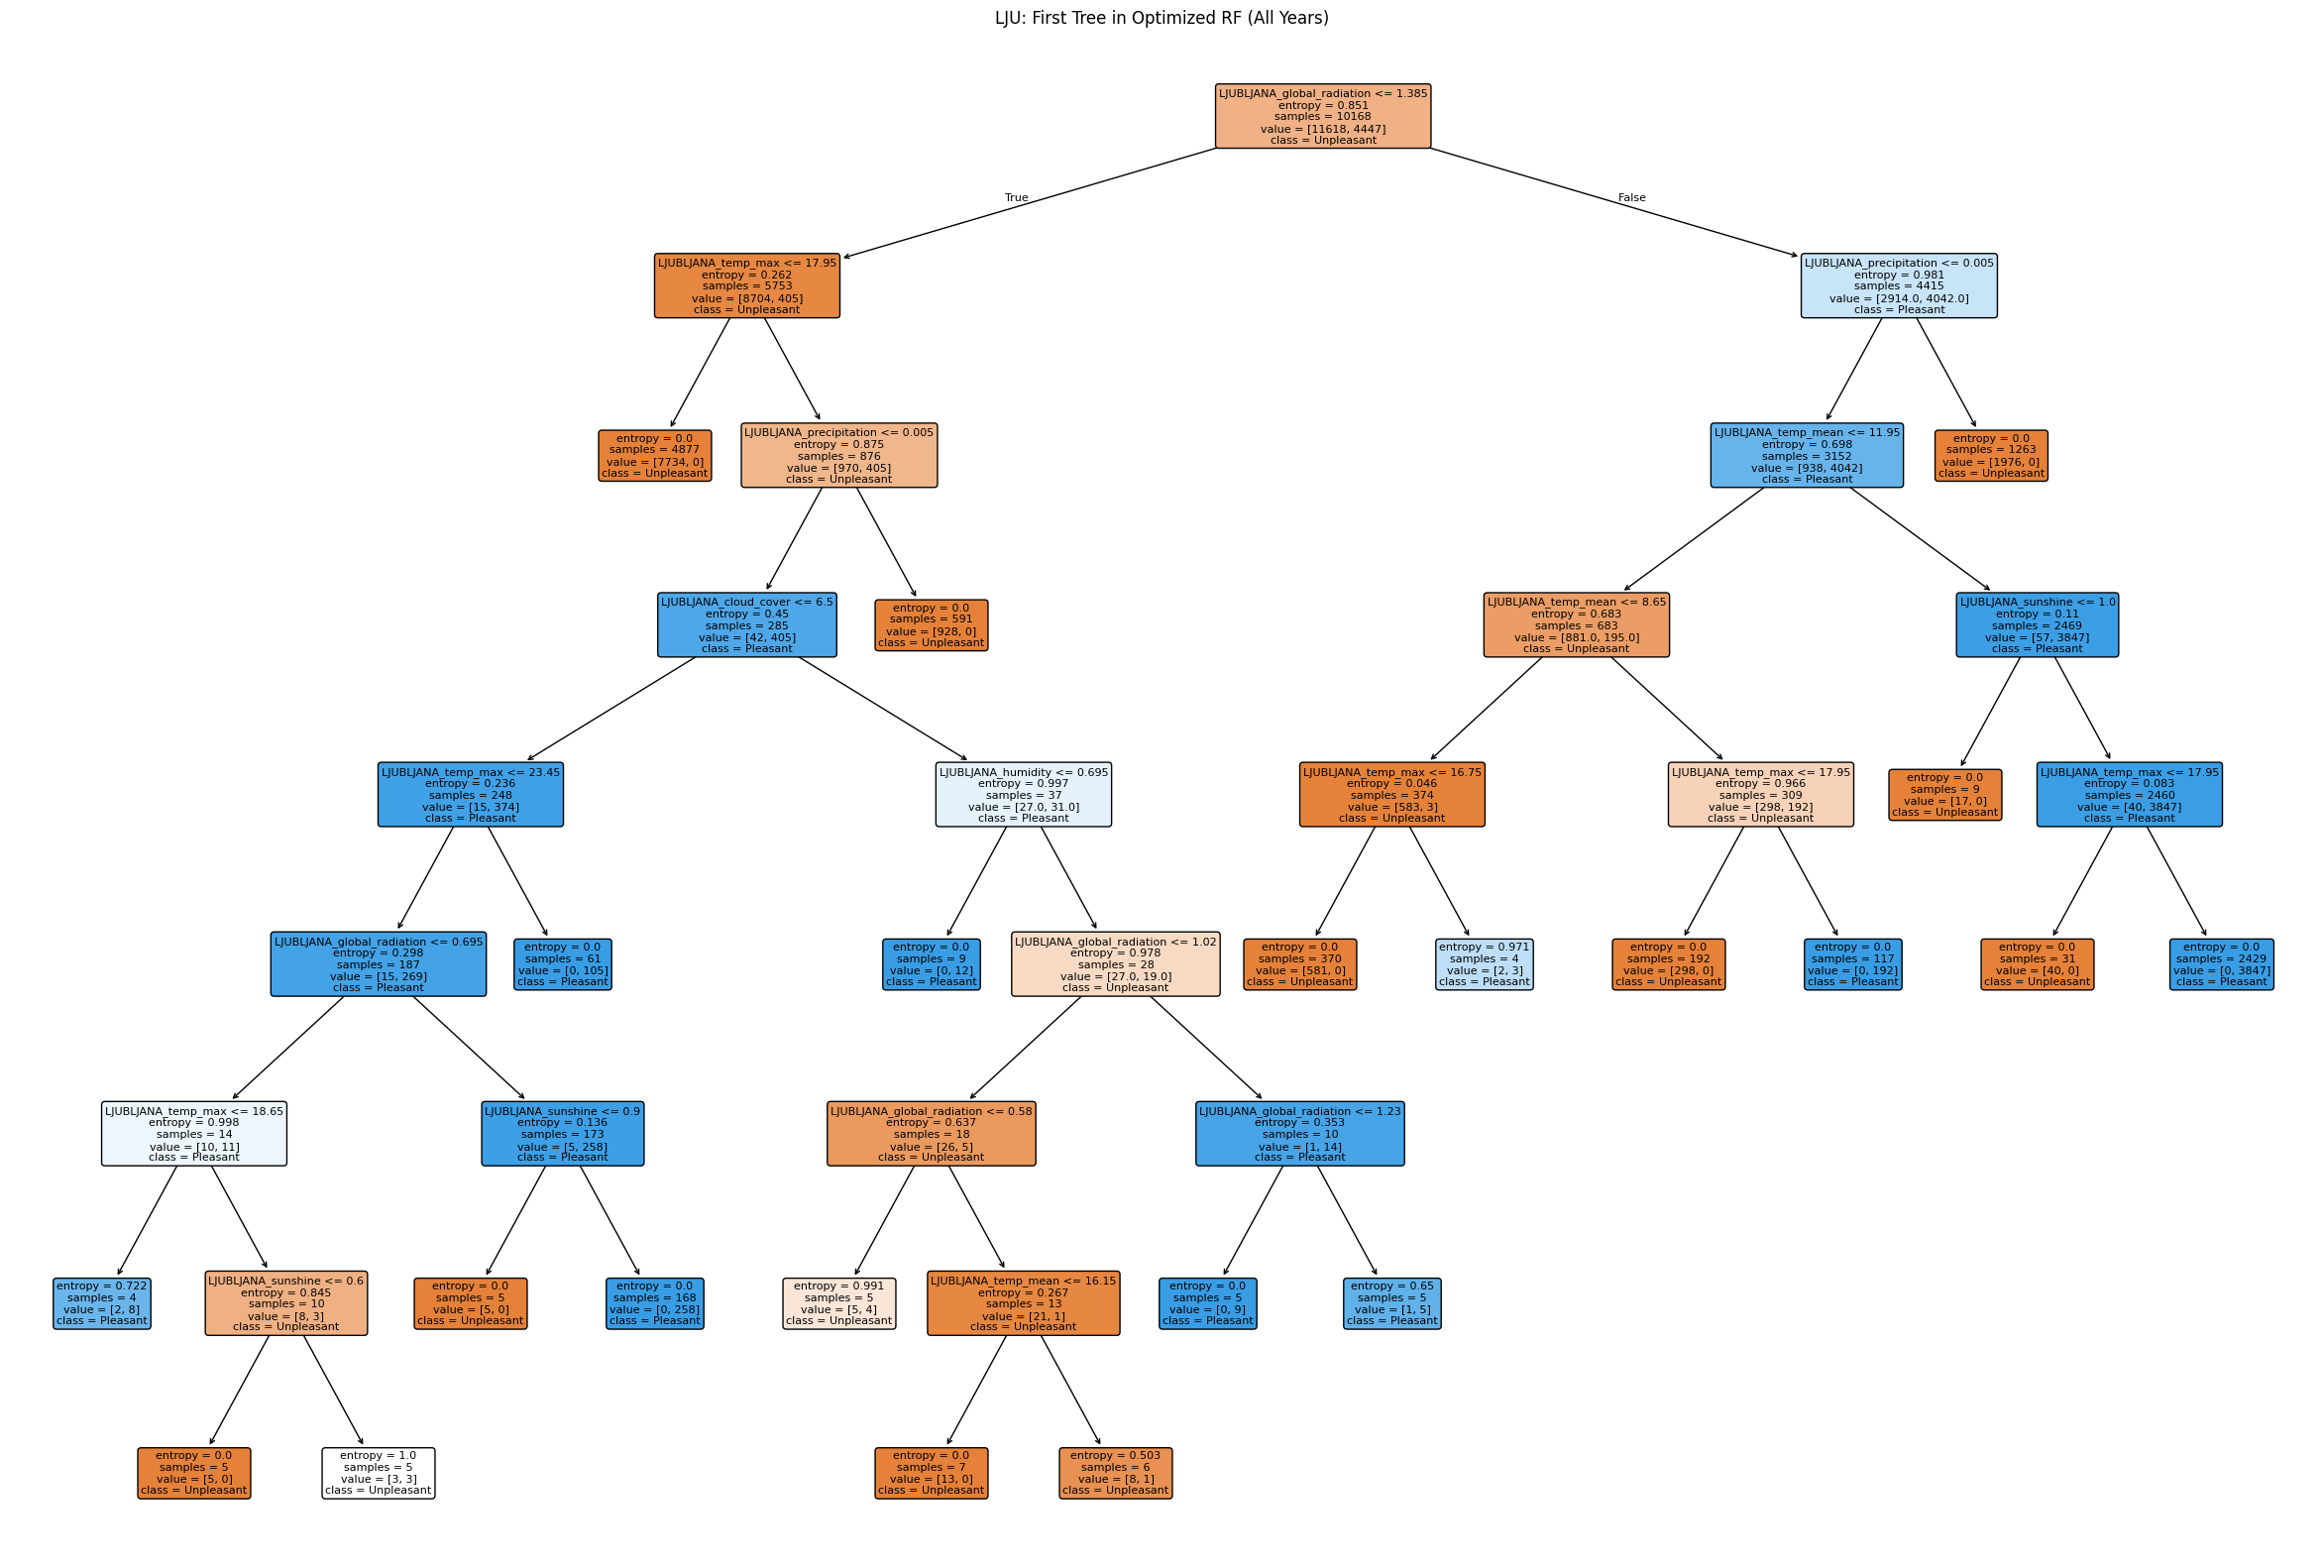

In [73]:
for station in top3:
    clf = rf_models[station]  # <- tuned model!
    features = data_splits[station]['X_train'].columns

    plt.figure(figsize=(30, 20))  # Large figure for full tree
    plot_tree(
        clf.estimators_[0],  # First tree of the forest
        filled=True,
        rounded=True,
        feature_names=features,
        class_names=['Unpleasant', 'Pleasant'],
        fontsize=8
    )
    plt.title(f"{station}: First Tree in Optimized RF (All Years)")
    plt.show()
